# Explaining the XGBoost diabetes model

This notebook contains **explanations only**. Train the model first with `python diabetes_xgboost.py` from `XGBOOST`; training, tuning, and evaluation live in that script. The notebook reloads the saved model and reconstructs the exact stratified holdout from its saved Hydra configuration.

The analysis follows the course material: week 1's built-in versus permutation feature importance, weeks 2–3's LIME and SHAP, and all tabular explanation approaches in `nn.ipynb` (two local cases, LIME stability, approximate global LIME, local/global SHAP, and comparisons). Tree models have no useful input gradient for saliency maps or noise tunnels: their predictions are piecewise constant, so those image-oriented methods are not applied here.

This dataset is observational. Feature attributions describe this model's predictions, **not causal effects or medical advice**.

In [1]:
from collections import Counter
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from lime.lime_tabular import LimeTabularExplainer
from omegaconf import OmegaConf
from scipy.stats import spearmanr
from sklearn.inspection import permutation_importance

from diabetes_xgboost import load_data, split_data

HERE = Path.cwd()
if not (HERE / 'diabetes_xgboost.py').exists():
    HERE = HERE / 'XAI_01' / 'XGBOOST'
artifact_dir = HERE / 'artifacts'
if not (artifact_dir / 'xgboost_model.joblib').exists():
    raise FileNotFoundError('Train first: run python diabetes_xgboost.py in XGBOOST.')

cfg = OmegaConf.load(artifact_dir / 'run_config.yaml')
model = joblib.load(artifact_dir / 'xgboost_model.joblib')
metrics = json.loads((artifact_dir / 'metrics.json').read_text(encoding='utf-8'))
X, y = load_data(cfg)
X_train, X_test, y_train, y_test = split_data(X, y, cfg)
feature_names = X.columns.tolist()
assert feature_names == metrics['feature_names'] == list(model.feature_names_in_)
class_names = ['No diabetes', 'Diabetes']
POS_LABEL = 1
print(f'Train: {len(X_train):,}; test: {len(X_test):,}; features: {len(feature_names)}')
print(f"Holdout accuracy: {metrics['accuracy']:.3f}; ROC-AUC: {metrics['roc_auc']:.3f}")
print(f"Tuning: {metrics['tuning_method'] or 'off'}; selected trees: {metrics['selected_estimators']}")
print('Confusion matrix (rows: actual 0/1, columns: predicted 0/1):')
print(np.asarray(metrics['confusion_matrix']))

C:\Users\bjorn\Desktop\Spaghetti\UberPython\XAI\XAI_01\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 56,553; test: 14,139; features: 21
Holdout accuracy: 0.754; ROC-AUC: 0.831
Tuning: optuna; selected trees: 166
Confusion matrix (rows: actual 0/1, columns: predicted 0/1):
[[4999 2071]
 [1409 5660]]


## Week 1 — global feature importance

XGBoost's built-in **gain** averages the improvements from splits on each feature. **Permutation importance** measures the change in holdout ROC-AUC after shuffling a column. The latter is evaluated on unseen data but can understate correlated or interchangeable features. The scores use different units, so compare rankings rather than raw magnitudes.

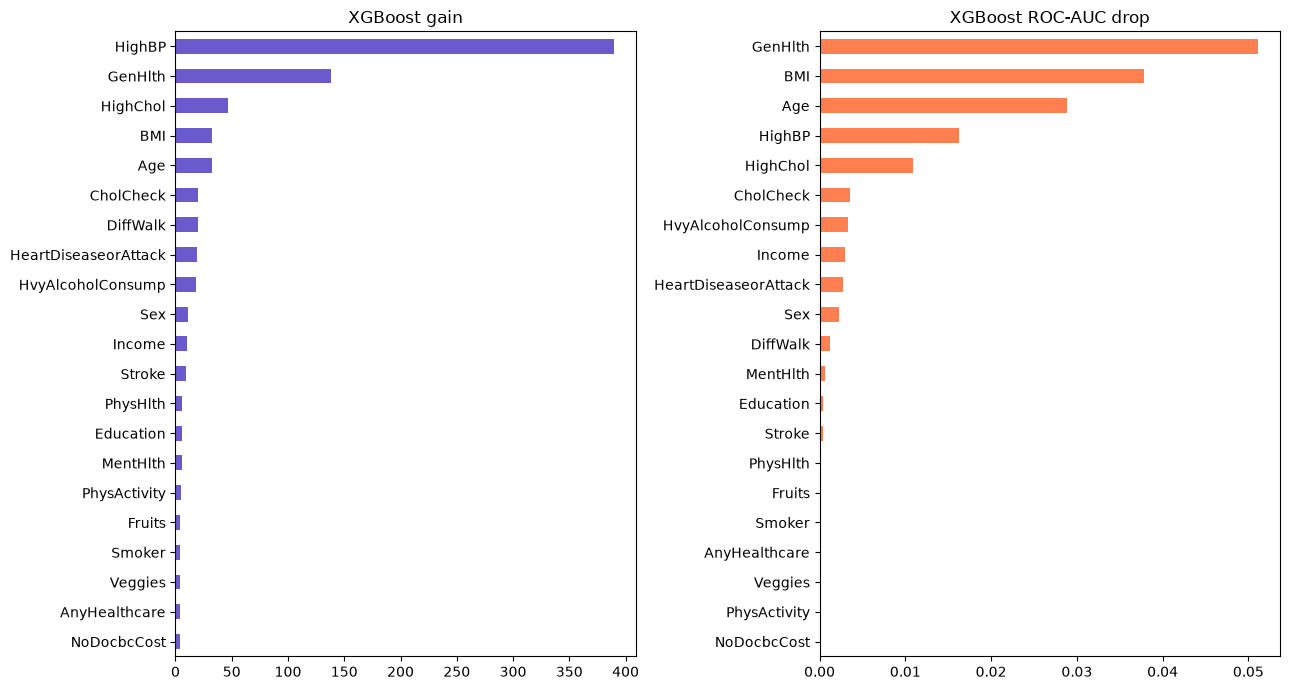

,gain,ROC-AUC drop
GenHlth,138.5235,0.0511
BMI,32.7447,0.0379
Age,32.2789,0.0289
HighBP,389.6992,0.0163
HighChol,46.3043,0.0109
CholCheck,20.3118,0.0035
HvyAlcoholConsump,18.0146,0.0033
Income,10.4467,0.0030
HeartDiseaseorAttack,19.1808,0.0027
Sex,11.3254,0.0022


Largest holdout ROC-AUC drop: GenHlth
Permutation values near zero indicate little unique predictive information under this test.


In [2]:
gain_raw = model.get_booster().get_score(importance_type='gain')
gain = pd.Series({name: gain_raw.get(name, 0.0) for name in feature_names}, name='gain')
permutation = permutation_importance(
    model, X_test, y_test, scoring='roc_auc', n_repeats=5,
    random_state=int(cfg.seed), n_jobs=1,
)
perm = pd.Series(permutation.importances_mean, index=feature_names, name='ROC-AUC drop')
importance = pd.concat([gain, perm], axis=1)
fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for ax, column, color in zip(axes, importance.columns, ['slateblue', 'coral']):
    importance[column].sort_values().plot.barh(ax=ax, color=color)
    ax.set_title(f'XGBoost {column}')
plt.tight_layout()
plt.show()
display(importance.sort_values('ROC-AUC drop', ascending=False).round(4))
print('Largest holdout ROC-AUC drop:', perm.idxmax())
print('Permutation values near zero indicate little unique predictive information under this test.')

## Weeks 2–3 — LIME local explanations

LIME perturbs a record, queries the fitted XGBoost model, weights nearby samples, and fits a local surrogate. Its coefficients are on the **diabetes probability** scale. We explain one prediction of each class, then inspect the local model fit and sensitivity to random perturbations. The training sample used to build LIME is fixed for repeatability.

Test row 0: P(diabetes)=0.923; local surrogate R²=0.560


,condition,LIME weight
0,BMI > 33.00,0.190922
1,HeartDiseaseorAttack <= 0.00,-0.161536
2,3.00 < GenHlth <= 4.00,0.117988
3,0.00 < HighBP <= 1.00,0.114459
4,0.00 < HighChol <= 1.00,0.085082
5,HvyAlcoholConsump <= 0.00,0.081492
6,9.00 < Age <= 11.00,0.066821
7,Income <= 4.00,0.056825
8,Sex <= 0.00,-0.033084
9,Fruits <= 0.00,0.018379


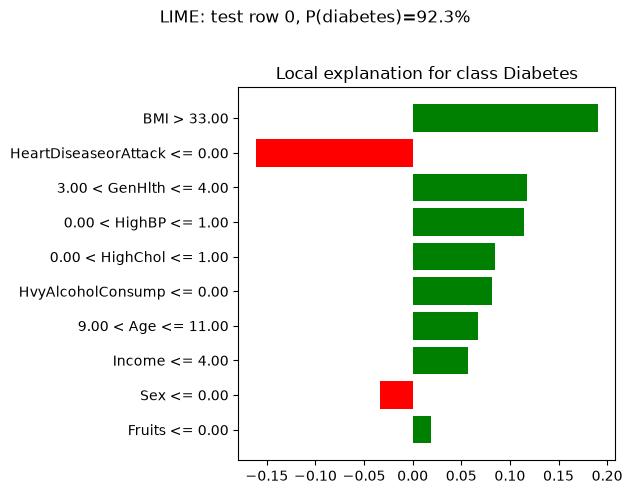

Test row 8257: P(diabetes)=0.008; local surrogate R²=0.670


,condition,LIME weight
0,GenHlth <= 2.00,-0.160255
1,HeartDiseaseorAttack <= 0.00,-0.159327
2,Age <= 7.00,-0.129257
3,BMI <= 25.00,-0.121189
4,HighBP <= 0.00,-0.121131
5,HighChol <= 0.00,-0.080719
6,HvyAlcoholConsump <= 0.00,0.068205
7,PhysHlth <= 0.00,-0.045408
8,6.00 < Income <= 8.00,-0.039473
9,Sex <= 0.00,-0.030806


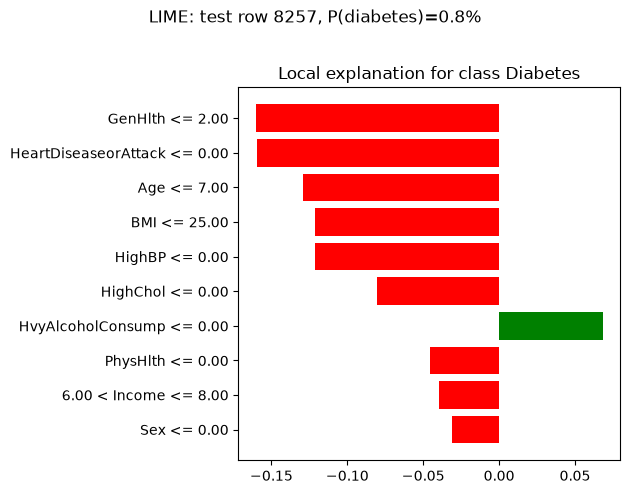

In [3]:
rng = np.random.default_rng(int(cfg.seed))
lime_training = X_train.iloc[rng.choice(len(X_train), size=min(3000, len(X_train)), replace=False)]

def make_lime(seed):
    return LimeTabularExplainer(
        training_data=lime_training.to_numpy(), feature_names=feature_names,
        class_names=class_names, mode='classification', random_state=seed,
    )

lime_explainer = make_lime(int(cfg.seed))
predicted = model.predict(X_test)
positive_index = int(np.flatnonzero(predicted == 1)[0])
negative_index = int(np.argmin(model.predict_proba(X_test)[:, POS_LABEL]))

def explain_lime(index, explainer=lime_explainer, num_features=10, num_samples=2000):
    return explainer.explain_instance(
        X_test.iloc[index].to_numpy(), model.predict_proba,
        labels=(POS_LABEL,), num_features=num_features, num_samples=num_samples,
    )

positive_lime = explain_lime(positive_index)
negative_lime = explain_lime(negative_index)
for index, explanation in [(positive_index, positive_lime), (negative_index, negative_lime)]:
    probability = model.predict_proba(X_test.iloc[[index]])[0, POS_LABEL]
    print(f'Test row {index}: P(diabetes)={probability:.3f}; local surrogate R²={explanation.score:.3f}')
    display(pd.DataFrame(explanation.as_list(label=POS_LABEL), columns=['condition', 'LIME weight']))
    fig = explanation.as_pyplot_figure(label=POS_LABEL)
    fig.suptitle(f'LIME: test row {index}, P(diabetes)={probability:.1%}', y=1.02)
    plt.tight_layout()
    plt.show()

### LIME stability on the same record

We explain the **same** positive prediction with different LIME seeds. Counts show how often a feature enters the top five; they are not a measure of model uncertainty. Low surrogate R² or unstable selections make the local account less reliable.

In [4]:
N_RUNS, TOP_K = 8, 5
selection_counts = Counter()
local_fit = []
for seed in range(N_RUNS):
    e = explain_lime(positive_index, make_lime(seed), num_features=TOP_K, num_samples=1000)
    selection_counts.update(feature_names[feature_id] for feature_id, _ in e.as_map()[POS_LABEL])
    local_fit.append(e.score)
stability = pd.DataFrame(selection_counts.most_common(), columns=['feature', f'selections / {N_RUNS}'])
display(stability)
print(f'Mean local surrogate R² across seeds: {np.mean(local_fit):.3f}')

,feature,selections / 8
0,BMI,8
1,HeartDiseaseorAttack,8
2,HighBP,8
3,GenHlth,8
4,HighChol,8


Mean local surrogate R² across seeds: 0.495


### Approximate global LIME importance

Following `nn.ipynb`, average absolute local coefficients across a fixed sample of test cases. This is a summary of local surrogates, not a global explanation of the underlying trees. Zeros are included when a feature receives no coefficient.

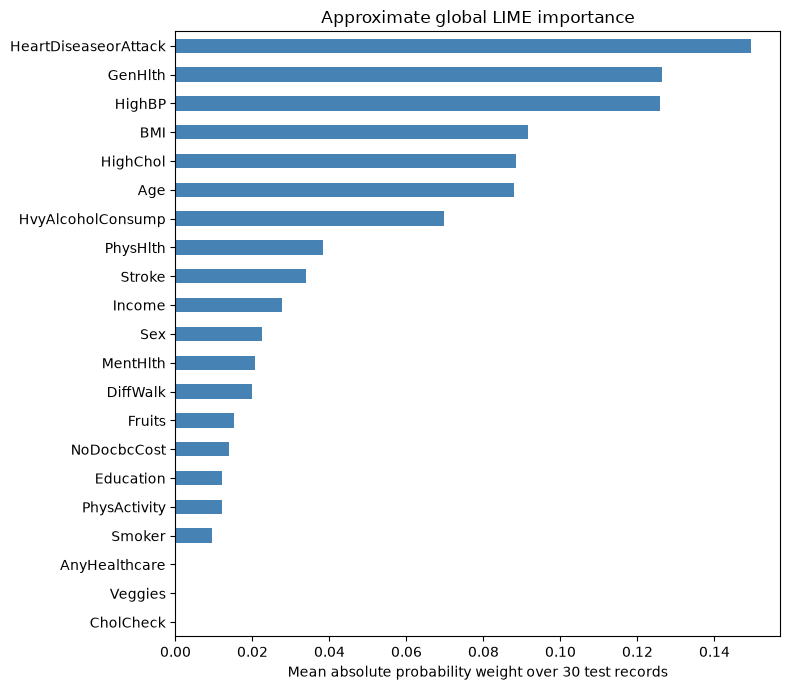

,mean |LIME weight|
HeartDiseaseorAttack,0.1495
GenHlth,0.1263
HighBP,0.1259
BMI,0.0915
HighChol,0.0884
Age,0.0880
HvyAlcoholConsump,0.0698
PhysHlth,0.0384
Stroke,0.0338
Income,0.0276


In [5]:
N_LIME = min(30, len(X_test))
sample_indices = rng.choice(len(X_test), size=N_LIME, replace=False)
local_weights = np.zeros((N_LIME, len(feature_names)))
for row, index in enumerate(sample_indices):
    e = explain_lime(int(index), num_features=len(feature_names), num_samples=500)
    for feature_id, weight in e.as_map()[POS_LABEL]:
        local_weights[row, feature_id] = weight
lime_global = pd.Series(np.abs(local_weights).mean(axis=0), index=feature_names, name='mean |LIME weight|')
lime_global.sort_values().plot.barh(figsize=(8, 7), color='steelblue', title='Approximate global LIME importance')
plt.xlabel(f'Mean absolute probability weight over {N_LIME} test records')
plt.tight_layout()
plt.show()
display(lime_global.sort_values(ascending=False).to_frame().round(4))

## Weeks 2–3 — SHAP local and global explanations

Tree SHAP distributes each prediction around an expected model output. The interventional background and `model_output='probability'` put SHAP values on the **same probability scale** as LIME. The waterfall charts explain the two records above; the beeswarm and mean absolute values summarize a sample of the holdout. The sample is deliberately capped because interventional SHAP can be slow.

SHAP background mean P(diabetes): 0.473
Test row 0: SHAP sum=0.923; model P(diabetes)=0.923


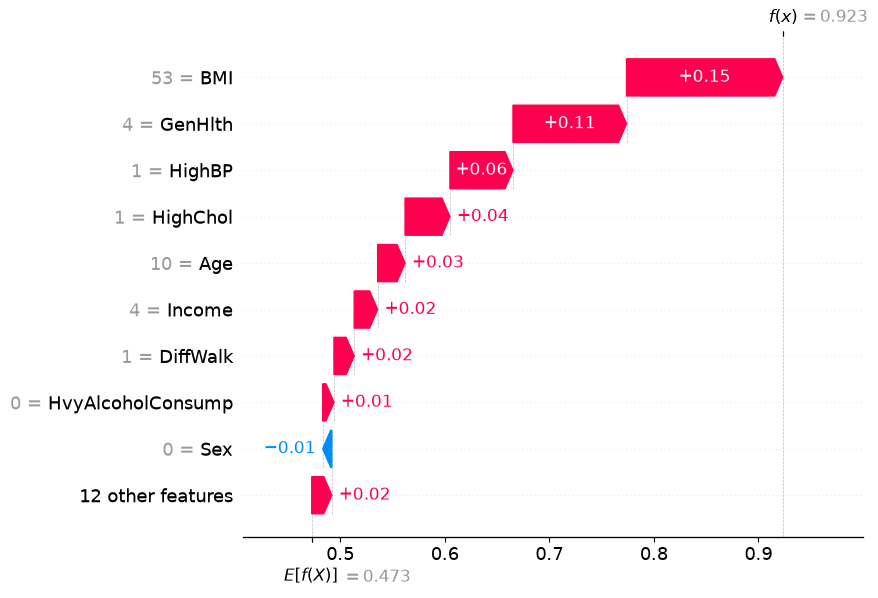

Test row 8257: SHAP sum=0.008; model P(diabetes)=0.008


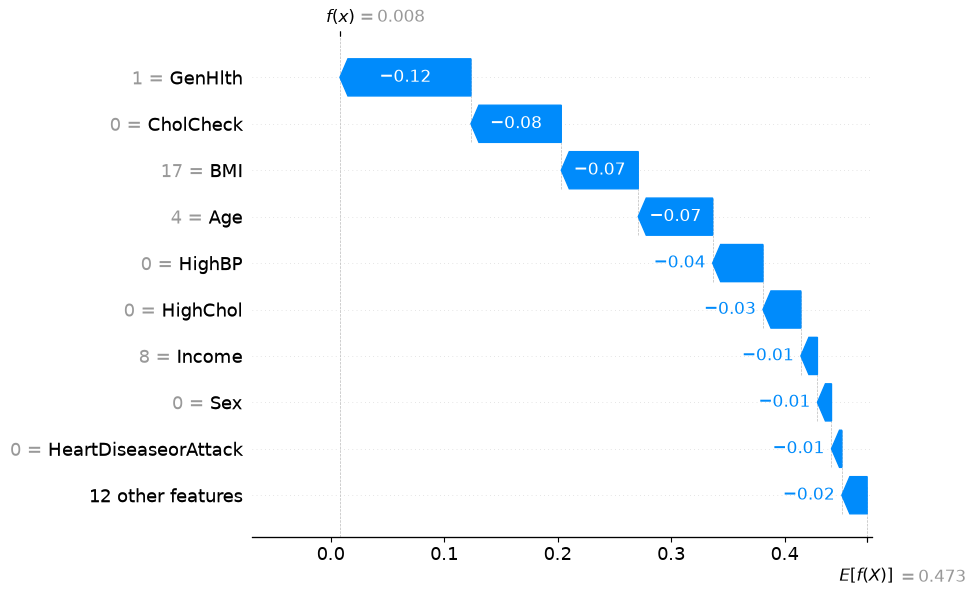

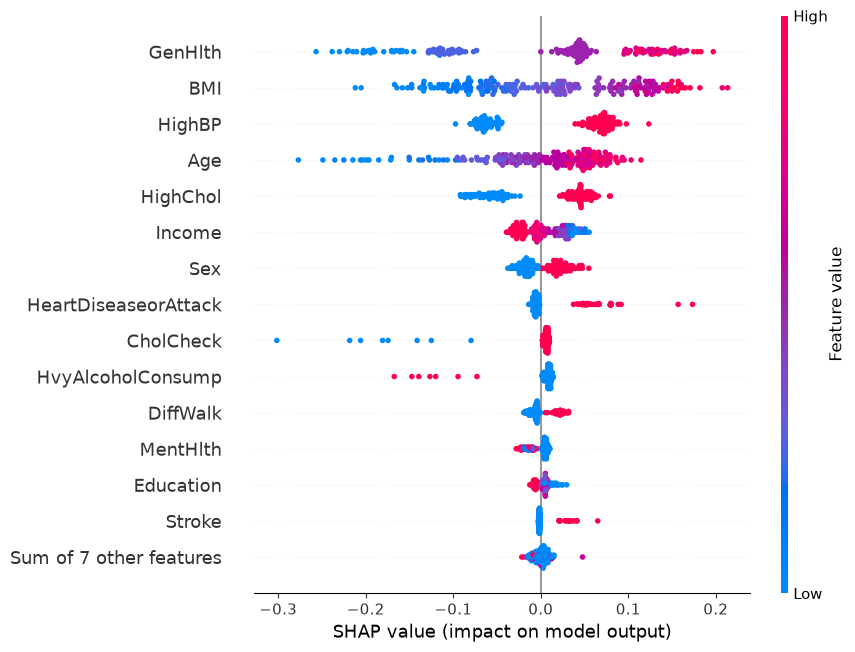

In [6]:
background = X_train.iloc[rng.choice(len(X_train), size=min(100, len(X_train)), replace=False)]
N_SHAP = min(200, len(X_test))
shap_indices = list(range(N_SHAP))
for index in (positive_index, negative_index):
    if index not in shap_indices:
        shap_indices.append(index)
X_shap = X_test.iloc[shap_indices]
shap_explainer = shap.TreeExplainer(
    model, data=background, feature_perturbation='interventional',
    model_output='probability',
)
shap_values = shap_explainer(X_shap)
print(f'SHAP background mean P(diabetes): {float(np.mean(shap_values.base_values)):.3f}')
for index in (positive_index, negative_index):
    position = shap_indices.index(index)
    reconstructed = float(shap_values.base_values[position] + shap_values.values[position].sum())
    probability = float(model.predict_proba(X_test.iloc[[index]])[0, POS_LABEL])
    print(f'Test row {index}: SHAP sum={reconstructed:.3f}; model P(diabetes)={probability:.3f}')
    shap.plots.waterfall(shap_values[position], max_display=10)
shap.plots.beeswarm(shap_values, max_display=15)

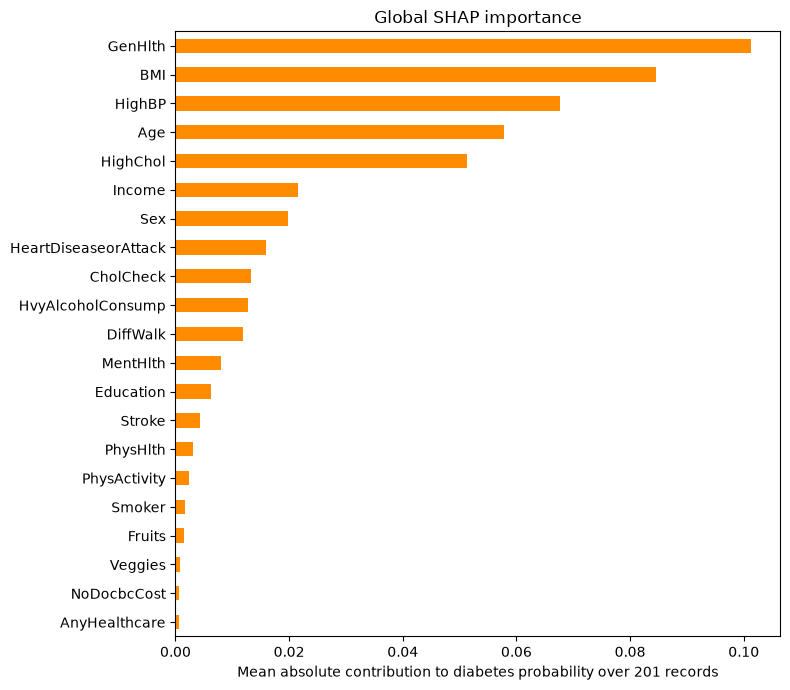

,mean |SHAP|
GenHlth,0.1013
BMI,0.0846
HighBP,0.0677
Age,0.0578
HighChol,0.0512
Income,0.0215
Sex,0.0199
HeartDiseaseorAttack,0.0159
CholCheck,0.0133
HvyAlcoholConsump,0.0127


Largest mean absolute SHAP contribution: GenHlth


In [7]:
shap_global = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=feature_names, name='mean |SHAP|'
)
shap_global.sort_values().plot.barh(figsize=(8, 7), color='darkorange', title='Global SHAP importance')
plt.xlabel(f'Mean absolute contribution to diabetes probability over {len(X_shap)} records')
plt.tight_layout()
plt.show()
display(shap_global.sort_values(ascending=False).to_frame().round(4))
print('Largest mean absolute SHAP contribution:', shap_global.idxmax())

## Compare LIME and SHAP

The side-by-side chart uses the **same positive record**. SHAP allocates the model prediction relative to a background; LIME fits a neighborhood surrogate. Thus even on a common probability scale, their values need not coincide. The global comparison ranks absolute values and uses Spearman correlation; its p-value is descriptive because feature scores are dependent and these are sampled explanations.

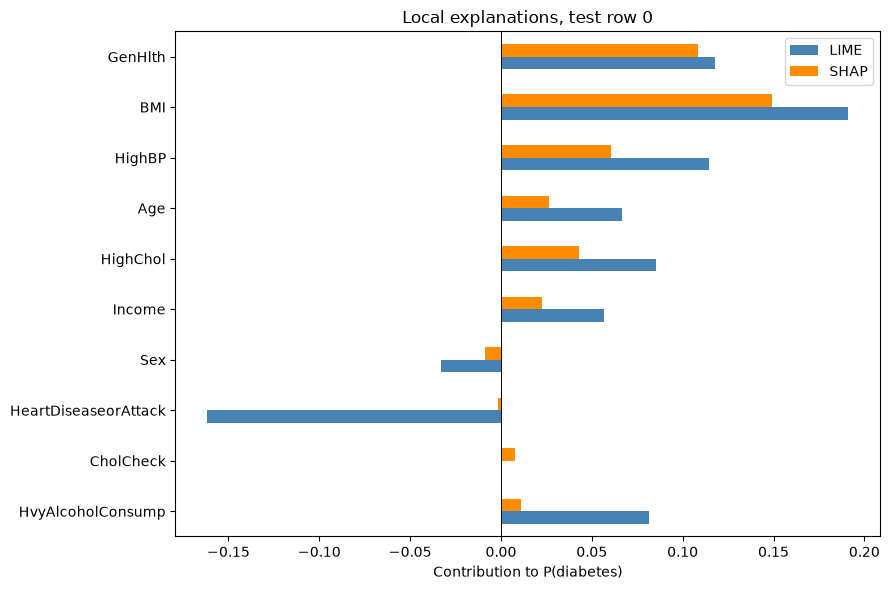

,LIME,SHAP
GenHlth,0.1180,0.1086
BMI,0.1909,0.1494
HighBP,0.1145,0.0603
Age,0.0668,0.0262
HighChol,0.0851,0.0429
Income,0.0568,0.0224
Sex,-0.0331,-0.0087
HeartDiseaseorAttack,-0.1615,-0.0018
CholCheck,0.0000,0.0075
HvyAlcoholConsump,0.0815,0.0107


The methods agree on direction for 9 of 10 displayed features.


In [8]:
lime_local = pd.Series(0.0, index=feature_names)
for feature_id, weight in positive_lime.as_map()[POS_LABEL]:
    lime_local.iloc[feature_id] = weight
shap_local = pd.Series(shap_values.values[shap_indices.index(positive_index)], index=feature_names)
top_features = shap_global.nlargest(10).index
comparison = pd.DataFrame({'LIME': lime_local[top_features], 'SHAP': shap_local[top_features]})
comparison.iloc[::-1].plot.barh(figsize=(9, 6), color=['steelblue', 'darkorange'])
plt.axvline(0, color='black', linewidth=0.7)
plt.xlabel('Contribution to P(diabetes)')
plt.title(f'Local explanations, test row {positive_index}')
plt.tight_layout()
plt.show()
display(comparison.round(4))
print('The methods agree on direction for', int((np.sign(comparison.LIME) == np.sign(comparison.SHAP)).sum()), 'of 10 displayed features.')

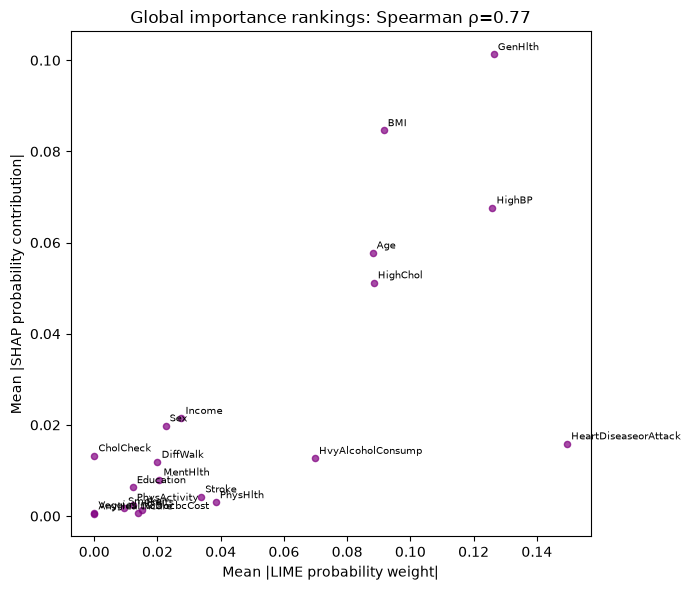

Spearman ρ=0.771, descriptive p=4.28e-05
Top five LIME: HeartDiseaseorAttack, GenHlth, HighBP, BMI, HighChol
Top five SHAP: GenHlth, BMI, HighBP, Age, HighChol


In [9]:
aligned = pd.DataFrame({'LIME': lime_global, 'SHAP': shap_global})
rho, p_value = spearmanr(aligned.LIME, aligned.SHAP)
ax = aligned.plot.scatter(x='LIME', y='SHAP', figsize=(7, 6), color='purple', alpha=0.7)
for feature, row in aligned.iterrows():
    ax.annotate(feature, (row.LIME, row.SHAP), fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.set_title(f'Global importance rankings: Spearman ρ={rho:.2f}')
ax.set_xlabel('Mean |LIME probability weight|')
ax.set_ylabel('Mean |SHAP probability contribution|')
plt.tight_layout()
plt.show()
print(f'Spearman ρ={rho:.3f}, descriptive p={p_value:.3g}')
print('Top five LIME:', ', '.join(lime_global.nlargest(5).index))
print('Top five SHAP:', ', '.join(shap_global.nlargest(5).index))

### Observations from the Optuna-tuned run

Both tuning methods now use the same configured search space. In this run, Optuna evaluated **20 trials** and selected a **235-tree limit** with cross-validated ROC-AUC **0.8311**. Early stopping chose **166 trees** for the final model. On the balanced holdout, accuracy was **0.754** and ROC-AUC was **0.831**. `GenHlth` caused the largest holdout ROC-AUC drop under permutation (about **0.051**) and led mean absolute SHAP importance, while `HighBP` led built-in gain. These importance measures answer different questions.

The LIME local surrogate R² values were **0.560** and **0.670** for the two example records; repeated explanations of the positive case averaged **0.495**, so individual LIME weights warrant caution. SHAP contributions reconstructed both model probabilities to three decimals. Global LIME–SHAP rankings had **Spearman ρ=0.771** on their sampled explanations. These results describe model behavior and do not imply causation. If you retrain, the printed results above become the current results.

### Reading these results

- A positive local attribution raises the modeled diabetes probability relative to that method's reference; a negative one lowers it.
- SHAP values should reconstruct the printed model probabilities up to numerical tolerance. LIME's printed surrogate R² and repeated-selection counts help assess its local approximation.
- Built-in gain, holdout permutation, global LIME, and global SHAP answer different questions. Agreement strengthens a descriptive pattern; disagreement can reflect correlated features, different reference distributions, or a weak LIME surrogate.
- The source data are survey indicators. These plots do not establish that changing a feature would change a person's outcome.